Import libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.data import random_split
import numpy as np
import matplotlib.pyplot as plt

We will check if we have a GPU available to use

In [ ]:
# Use a GPU if available.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


By default PyTorch stores images as PIL images so we will convert them to tensors and normalize them.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

Now we load both the train and test dataset

In [ ]:
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

now we Perform an 80% – 20% train-validation split from the training data.


NB: We could have skip this operation but the requirement want us to do this

In [ ]:
# Compute split sizes
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

# Shuffle before splitting using a fixed random seed
generator = torch.Generator().manual_seed(42)

# Split the dataset
train_dataset, test_dataset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=generator
)

print(f"Training samples: {len(train_dataset)}")

print(f"Test samples: {len(test_dataset)}")

Training samples: 40000
Test samples: 10000


In [ ]:
train_dataset

we set our parameters

In [ ]:
batch_size = 64
learning_rate = 0.001
num_epochs = 10

now we create a  DataLoader: splits dataset into batches and shuffles them, then we shuffle=True: randomize order each epoch (helps prevent overfitting)

In [ ]:
# DataLoader: splits dataset into batches and shuffles them
# shuffle=True: randomize order each epoch (helps prevent overfitting)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

lets look at the shape of our train dataset

In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 3, 32, 32])
Label batch shape: torch.Size([64])


In [ ]:
labels

tensor([2, 8, 7, 4, 7, 7, 0, 6, 2, 9, 7, 7, 6, 2, 0, 0, 8, 3, 1, 6, 5, 5, 2, 9,
        0, 3, 0, 6, 2, 3, 6, 7, 7, 5, 9, 2, 8, 5, 5, 9, 9, 2, 9, 7, 9, 1, 1, 9,
        5, 8, 1, 3, 9, 7, 0, 4, 2, 1, 1, 5, 3, 8, 6, 3])

In [ ]:
# Name our labels
classes = (
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
)

we will crete visuals of our datatsets

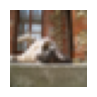

Label: cat


In [ ]:
plt.figure(figsize=(1,1))

# Function to display an image
def imshow(img):
    img = img / 2 + 0.5          # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get one batch
images, labels = next(iter(train_loader))

# Show the first image
imshow(images[1])

print("Label:", classes[labels[1]])

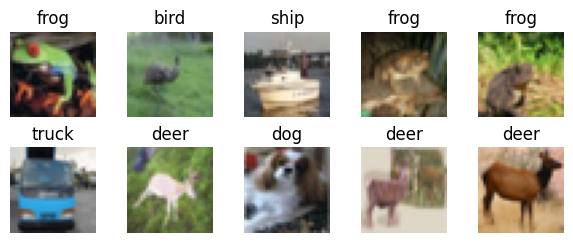

In [ ]:
import matplotlib.pyplot as plt

# Class names

fig, axes = plt.subplots(2, 5, figsize=(6,2.5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    # Undo normalization
    image = image * 0.5 + 0.5

    # Convert CHW → HWC
    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

we create our Neural network architecture

In [ ]:
import torch.nn as nn

Model_architecture = nn.Sequential(

    # =====================================
    # Convolution Block 1
    # Input: 3 x 32 x 32
    # =====================================
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),      # Output: 32 x 16 x 16
    nn.Dropout(0.25),

    # =====================================
    # Convolution Block 2
    # =====================================
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),      # Output: 64 x 8 x 8
    nn.Dropout(0.25),

    # =====================================
    # Convolution Block 3
    # =====================================
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),      # Output: 128 x 4 x 4
    nn.Dropout(0.25),

    # =====================================
    # Fully Connected Layers
    # =====================================
    nn.Flatten(),

    # 128 × 4 × 4 = 2048
    nn.Linear(128 * 4 * 4, 256),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(256, 128),
    nn.ReLU(),

    nn.Linear(128, 10),
    #nn.Softmax(dim=1) i applied softmax and the acuuracy was very low, i checked and its because we already have binary cross enthropy that is expect raw logits and will apply internal soft max


)

print(Model_architecture)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Dropout(p=0.25, inplace=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Dropout(p=0.25, inplace=False)
  (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): ReLU()
  (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (11): Dropout(p=0.25, inplace=False)
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=2048, out_features=256, bias=True)
  (14): ReLU()
  (15): Dropout(p=0.5, inplace=False)
  (16): Linear(in_features=256, out_features=128, bias=True)
  (17): ReLU()
  (18): Linear(in_features=128, out_features=10, bias=True)
)




Model_architecture = nn.Sequential(

    # Input: 3 x 32 x 32
    nn.Conv2d(in_channels=3, out_channels=6, kernel_size=3, padding=1),
    nn.ReLU(),

    # Output: 6 x 32 x 32
    nn.MaxPool2d(kernel_size=2, stride=2),

    # Output: 6 x 16 x 16
    nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, padding=1),
    nn.ReLU(),

    # Output: 16 x 16 x 16
    nn.MaxPool2d(kernel_size=2, stride=2),

    # Output: 16 x 8 x 8
    nn.Flatten(),

    # 16 * 8 * 8 = 1024
    nn.Linear(16 * 8 * 8, 120),
    nn.ReLU(),

    nn.Dropout(0.5),

    nn.Linear(120, 10)
)

print(Model_architecture)

In [ ]:
# Initialize model
model = Model_architecture.to(device)

create parameters

In [ ]:
# Training components
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

we create a training loop that we will use to train our model for some amount of epoch

In [ ]:
# Training loop
def train(model, device, train_loader, optimizer, criterion, epoch):
    # Set model to training mode.
    model.train()

    train_loss = 0
    correct = 0
    total = 0
    losses = []

    # Loop through batches
    for batch_idx, (X, y) in enumerate(train_loader):
        # X: shape of data (batch_size, 3, 32, 32)
        # y: shape of labels (batch_size,)

        # Move data to the same device as the model (GPU/CPU)
        X, y = X.to(device), y.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward propagation
        pred = model(X)

        # Loss calculation
        loss = criterion(pred, y)

        # Backward propagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Metrics
        train_loss += loss.item()
        losses.append(loss.item())

        # Get the predicted class (digit with highest score)
        _, predicted = pred.max(1)

        total += y.size(0)  # Add current batch size to total count
        correct += predicted.eq(y).sum().item()  # Add correct predictions to count


        # Print progress every 100 batches
        if batch_idx % 100 == 0:
            print(f'Epoch: {epoch} [{batch_idx * len(X)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')


    # Calculate the average metrics
    avg_loss = train_loss / len(train_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy, losses

we create a function for model evaluation on our test dataset

In [ ]:
# Test function
def test(model, device, test_loader, criterion):
    # Switch to evaluation mode
    model.eval()

    test_loss = 0
    correct = 0
    total = 0
    losses = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            # Forward propagation
            pred = model(data)

            # Loss calculation
            loss = criterion(pred, target)

            # Metrics
            test_loss += loss.item()
            losses.append(loss.item())

            # Calculate accuracy
            _, predicted = pred.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

    # Calculate average metrics
    avg_loss = test_loss / len(test_loader)
    accuracy = 100. * correct / total

    print(f"\nTest set: Average loss: {avg_loss:.4f},"
          f"Accuracy: {correct}/{total} ({accuracy:.2f}%)\n")

    return avg_loss, accuracy, losses

now we implement our training and testing

In [ ]:
# Main training loop

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

train_losses_epoch_cum = []
test_losses_epoch_cum = []


for epoch in range(1, num_epochs + 1):

    train_loss, train_acc, train_losses_epoch = train(model, device, train_loader, optimizer, criterion, epoch)
    test_loss, test_acc, test_losses_epoch = test(model, device, test_loader, criterion)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    train_losses_epoch_cum.extend(train_losses_epoch)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    test_losses_epoch_cum.extend(test_losses_epoch)
print(f'learning rate: {learning_rate}')
print(f'optimizer: {optimizer}')
print("Training complete!")
print("=" * 60)

Epoch: 1 [0/40000 (0%)]	Loss: 2.295598
Epoch: 1 [6400/40000 (16%)]	Loss: 1.872843
Epoch: 1 [12800/40000 (32%)]	Loss: 1.534132
Epoch: 1 [19200/40000 (48%)]	Loss: 1.770157
Epoch: 1 [25600/40000 (64%)]	Loss: 1.450113
Epoch: 1 [32000/40000 (80%)]	Loss: 1.464690
Epoch: 1 [38400/40000 (96%)]	Loss: 1.524855

Test set: Average loss: 1.3263,Accuracy: 5111/10000 (51.11%)

Epoch: 2 [0/40000 (0%)]	Loss: 1.409787
Epoch: 2 [6400/40000 (16%)]	Loss: 1.576091
Epoch: 2 [12800/40000 (32%)]	Loss: 1.399841
Epoch: 2 [19200/40000 (48%)]	Loss: 1.174613
Epoch: 2 [25600/40000 (64%)]	Loss: 1.238912
Epoch: 2 [32000/40000 (80%)]	Loss: 1.411571
Epoch: 2 [38400/40000 (96%)]	Loss: 1.392157

Test set: Average loss: 1.1415,Accuracy: 5947/10000 (59.47%)

Epoch: 3 [0/40000 (0%)]	Loss: 1.154581
Epoch: 3 [6400/40000 (16%)]	Loss: 1.079148
Epoch: 3 [12800/40000 (32%)]	Loss: 1.413504
Epoch: 3 [19200/40000 (48%)]	Loss: 1.096805
Epoch: 3 [25600/40000 (64%)]	Loss: 1.198019
Epoch: 3 [32000/40000 (80%)]	Loss: 1.089837
Epoch: 3 [38

Training history saved to training_history.png


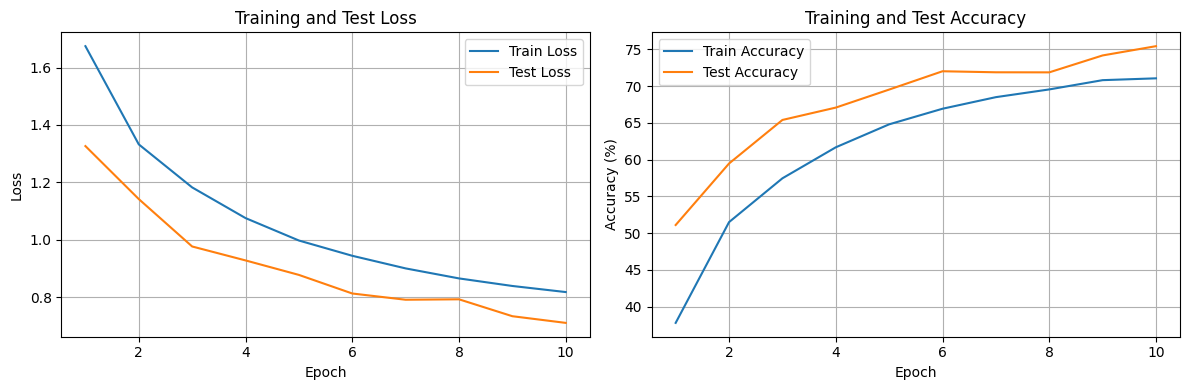

In [ ]:
# ============================================================================
# VISUALIZE TRAINING RESULTS
# ============================================================================

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# LEFT PLOT: Loss over epochs
# Loss should generally decrease over time
# If test loss starts increasing while train loss decreases, that's overfitting
ax1.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
ax1.plot(range(1, num_epochs + 1), test_losses, label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True)

# RIGHT PLOT: Accuracy over epochs
# Accuracy should generally increase over time
# Large gap between train and test accuracy indicates overfitting
ax2.plot(range(1, num_epochs + 1), train_accuracies, label='Train Accuracy')
ax2.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()  # Adjust spacing between subplots
plt.savefig('training_history.png')  # Save the figure
print('Training history saved to training_history.png')

now we create a confusion matrics to evaluate our model

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

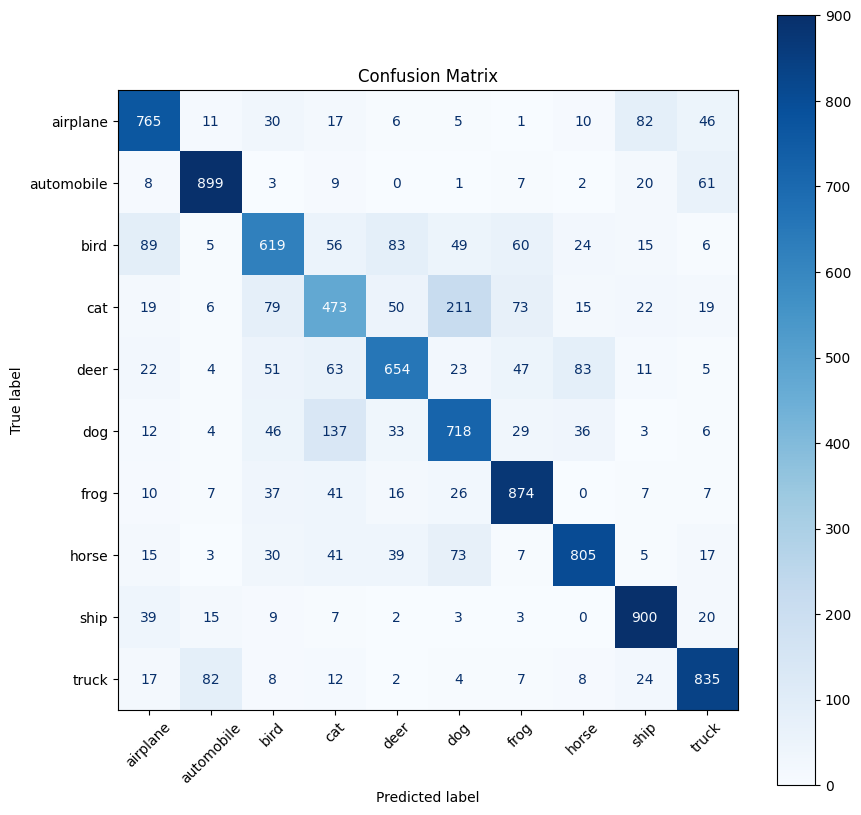

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10,10))

disp.plot(
    cmap='Blues',
    xticks_rotation=45,
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix")
plt.show()

now we display At least 5 correctly classified images

 also, At least 5 misclassified images

In [ ]:
import torch

model.eval()

correct_images = []
incorrect_images = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for image, label, pred in zip(images, labels, preds):

            if label == pred and len(correct_images) < 5:
                correct_images.append((image.cpu(), label.cpu(), pred.cpu()))

            elif label != pred and len(incorrect_images) < 5:
                incorrect_images.append((image.cpu(), label.cpu(), pred.cpu()))

            # Stop once we've collected enough
            if len(correct_images) == 5 and len(incorrect_images) == 5:
                break

        if len(correct_images) == 5 and len(incorrect_images) == 5:
            break

In [ ]:
import matplotlib.pyplot as plt

def show_images(images, title):

    fig, axes = plt.subplots(1, 5, figsize=(6,2))
    fig.suptitle(title, fontsize=16)

    for ax, (image, label, pred) in zip(axes, images):

        # Undo normalization
        image = image * 0.5 + 0.5

        image = image.permute(1,2,0)

        ax.imshow(image)

        ax.set_title(
            f"True: {classes[label]}\nPred: {classes[pred]}",
            fontsize=9
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

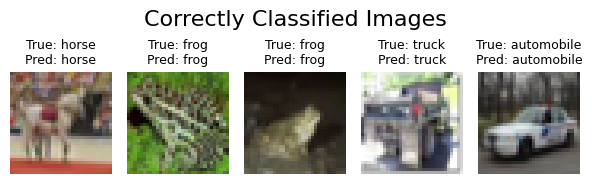

In [ ]:
show_images(correct_images, "Correctly Classified Images")

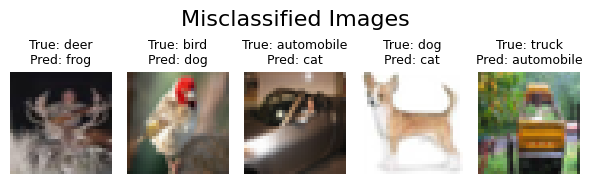

In [ ]:
show_images(incorrect_images, "Misclassified Images")